<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/wine_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

회귀 문제: residual sugar를 예측

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [143]:
red_wine = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-red.csv',  sep=';')
white_wine = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-white.csv',  sep=';')

In [144]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [145]:
white_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [146]:
# 결측치 개수 파악
red_wine.isnull().sum().to_frame('nan_count')
# 결측치 비율 파악
pd.DataFrame(data=red_wine.isnull().sum()/len(red_wine),columns=['nan_ratio'])

,nan_ratio
fixed acidity,0.0
volatile acidity,0.0
citric acid,0.0
residual sugar,0.0
chlorides,0.0
free sulfur dioxide,0.0
total sulfur dioxide,0.0
density,0.0
pH,0.0
sulphates,0.0


In [147]:
# 결측치 개수 파악
white_wine.isnull().sum().to_frame('nan_count')
# 결측치 비율 파악
pd.DataFrame(data=white_wine.isnull().sum()/len(white_wine),columns=['nan_ratio'])

,nan_ratio
fixed acidity,0.0
volatile acidity,0.0
citric acid,0.0
residual sugar,0.0
chlorides,0.0
free sulfur dioxide,0.0
total sulfur dioxide,0.0
density,0.0
pH,0.0
sulphates,0.0


In [148]:
# 구조가 동일하므로 레드 와인/화이트 와인 데이터를 연결
# wine 'color' 컬럼 추가하여 구분
red_wine['color'] = 1.
white_wine['color'] = 0.

wine = pd.concat([red_wine, white_wine])
wine.reset_index(drop=True, inplace=True)
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 660.0 KB


fixed acidity : 고정 산도
volatile acidity : 휘발성 산도
citric acid : 시트르산
residual sugar : 잔류 당분
chlorides : 염화물
free sulfur dioxide : 자유 이산화황
total sulfur dioxide : 총 이산화황
density : 밀도
pH
sulphates : 황산염
alcohol
quality : 0 ~ 10(높을 수록 좋은 품질)

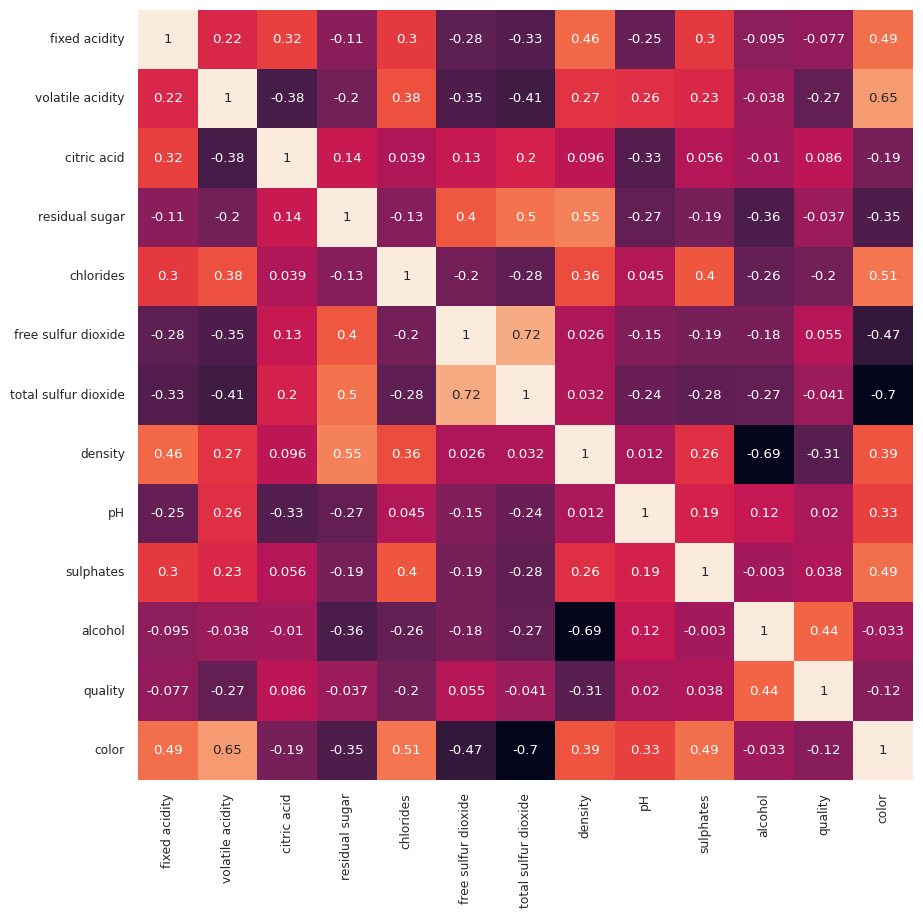

In [149]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
data_corr=wine.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(data_corr, annot=True, cbar=False)
plt.show()

# residual sugar와 가장 상관성 강한 건 density

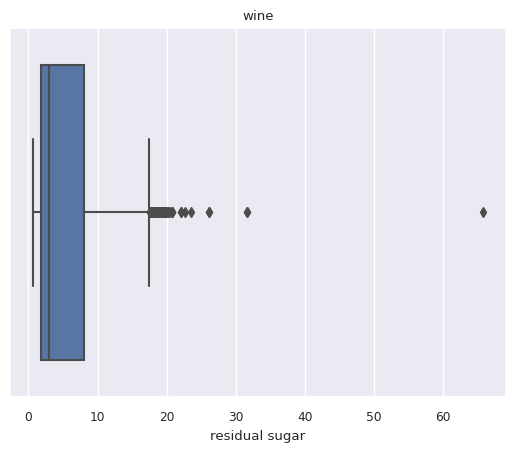

In [150]:
sns.boxplot(x='residual sugar', data=wine)
plt.title("wine")
plt.show()

####Set x and y values

In [151]:
y = wine['residual sugar']
y.head()

0    1.9
1    2.6
2    2.3
3    1.9
4    1.9
Name: residual sugar, dtype: float64

In [152]:
# 상관관계 낮은 것 제거
columns_to_drop = ['residual sugar', 'volatile acidity', 'sulphates']
X = wine.drop(columns=columns_to_drop, axis=1)

In [153]:
# train/test 8:2비율로 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(5197, 10) (5197,)
(1300, 10) (1300,)


In [154]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ly_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ly_preds, y_test))
print('평균제곱근오차', mse)
# RMSE는 MAE에 비해 직관성은 떨어지지만 Robust한 성격(극단적이지 않은 성격)에서 강점을 보인다.
# 즉 학습에 있어서 극단적인 데이터값이 들어가 있어도 잘 휘둘리지 않는다.

평균제곱근오차 1.4933002946067828


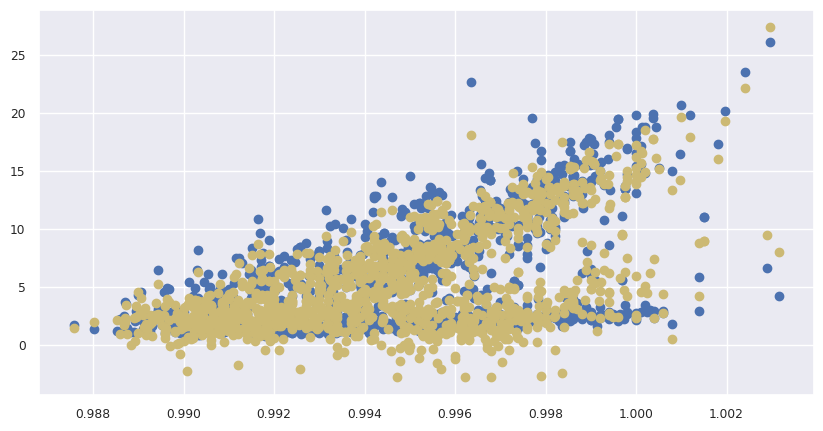

In [155]:
# 예측값과 실제 값 차이를 산접도로 표시, 노란색 예측

plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ly_preds, c='y', label='ly_preds')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show()

In [156]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(dy_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.6352456753660654


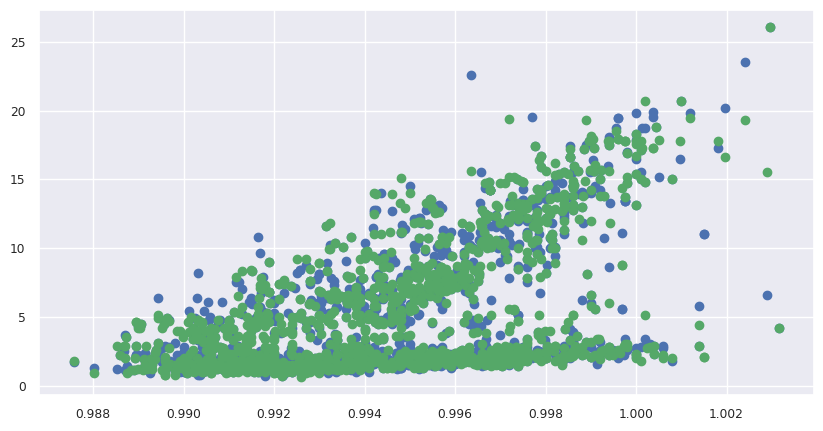

In [157]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], dy_preds, c='g', label='dy_preds')
plt.show()

In [158]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ry_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.268535897512016


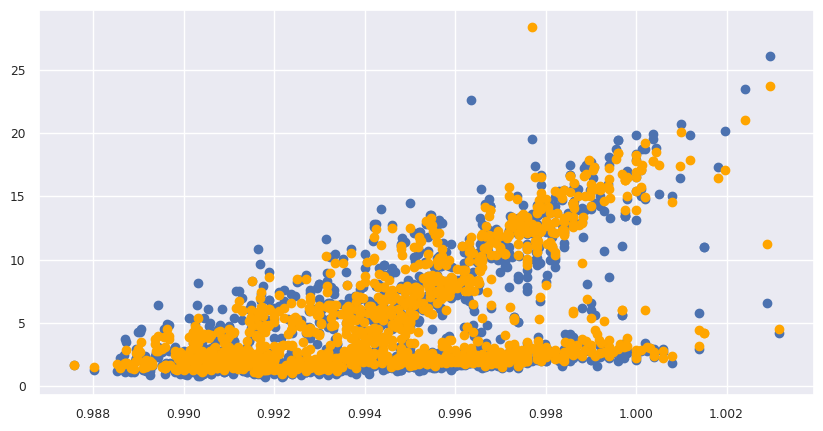

In [159]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ry_preds, c='orange', label='ry_preds')

plt.show()

In [160]:
from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
mse = np.sqrt(mean_squared_error(ry_preds, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 3.781017865523843


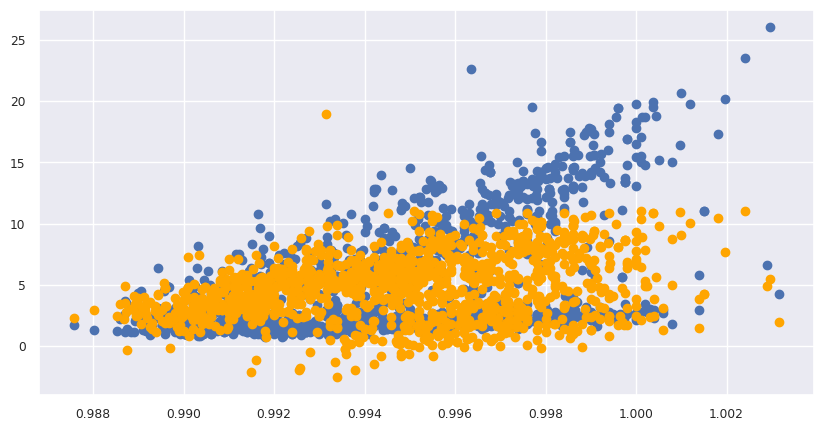

In [161]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['density'], y_test, label='y_test')
plt.scatter(X_test['density'], ry_preds, c='orange', label='ry_preds')

plt.show()

###KFold 교차검증

In [162]:
# 다시 train set을 8:2로 나눠서 validation set까지 만들기
X_sub, X_valid, y_sub, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(X_sub.shape, X_valid.shape)

(4157, 10) (1040, 10)


In [163]:
from sklearn.tree import DecisionTreeRegressor

clf_dt = DecisionTreeRegressor()
clf_dt.fit(X_sub, y_sub)


print(clf_dt.score(X_sub, y_sub))
print(clf_dt.score(X_valid, y_valid))

0.9999982281061386
0.8927065722177666


In [164]:
# 교차 검증 진행
from sklearn.model_selection import cross_validate
scores = cross_validate(clf_dt, X_train, y_train)
print(scores)

{'fit_time': array([0.03186989, 0.02789378, 0.02741838, 0.02776432, 0.02775407]), 'score_time': array([0.0023303 , 0.00158525, 0.00156379, 0.00166988, 0.00161362]), 'test_score': array([0.90126838, 0.87633284, 0.87863065, 0.87925058, 0.83319498])}


In [165]:
print(np.mean(scores['test_score']))

0.8737354836100449


In [166]:
from sklearn.model_selection import KFold
splitter = KFold(n_splits=10,shuffle=True, random_state=42)
scores = cross_validate(clf_dt, X_train, y_train, cv=splitter)
print(np.mean(scores['test_score'])) # 검증 점수

0.8799470042286884


In [167]:
# 그리드 서치
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

In [168]:
gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, n_jobs=-1)

In [169]:
gs.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0001, 0.0002, 0.0003,
                                                   0.0004, 0.0005]})

In [170]:
dt = gs.best_estimator_
print(dt.score(X_train, y_train))

0.9959173875409156


In [171]:
print(gs.best_params_) # 그리드 서치로 찾은 최적의 매개변수: best_params_속성에 저장되어 있음

{'min_impurity_decrease': 0.0002}


In [172]:
print(gs.cv_results_['mean_test_score'])

[0.87318042 0.87887548 0.87796549 0.87237163 0.87267696]


In [173]:
best_index = np.argmax(gs.cv_results_['mean_test_score']) # argmax(): 가장 큰 값의 인덱스를 추출
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0002}


In [174]:
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001), # 0.0001에서 0.001까지 0.0001을 계속 더한 배열 : 9개
          'max_depth': range(5, 20, 1), # 트리 깊이 제한 - 5에서 20까지 1씩 증가하면서 15개의 값 만들기
          'min_samples_split': range(2, 100, 10) # 2에서 100까지 10씩 증가하면서 10개의 값 만듬
          }
        # 검증횟수: 9 * 15 * 10 = 1350개

In [175]:
gs = GridSearchCV(DecisionTreeRegressor(random_state=42), params, n_jobs=-1)
gs.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'min_impurity_decrease': array([0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008,
       0.0009]),
                         'min_samples_split': range(2, 100, 10)})

In [176]:
# 최상의 매개변수 조합
print(gs.best_params_)

{'max_depth': 17, 'min_impurity_decrease': 0.0002, 'min_samples_split': 2}


In [177]:
# 최상의 교차 검증 점수
print(np.max(gs.cv_results_['mean_test_score']))

0.8798244591666486


###랜덤 서치

In [178]:
from scipy.stats import uniform, randint

rgen = randint(0,10) # 정수값 뽑기
rgen.rvs(10)

array([9, 5, 4, 0, 3, 3, 5, 1, 7, 6])

In [179]:
np.unique(rgen.rvs(1000), return_counts=True) # 1000개를 샘플링해서 각 숫자의 개수를 세어봄. 고르다.

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 95,  85, 100, 102,  90, 106,  93, 112, 101, 116]))

In [180]:
ugen = uniform(0, 1) # 실수값 뽑기
ugen.rvs(10)

array([0.48759619, 0.67018703, 0.00698279, 0.42198282, 0.58050522,
       0.80317226, 0.50232884, 0.00789092, 0.93866053, 0.74602629])

In [181]:
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }
          # 샘플링 횟수는 RandomizedSearchCV 클래스의 n_iter 매개변수에 저장됨

In [182]:
from sklearn.model_selection import RandomizedSearchCV

gs = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(X_train, y_train)

RandomizedSearchCV(estimator=DecisionTreeRegressor(random_state=42), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a254a10ec80>,
                                        'min_impurity_decrease': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7a254a10e710>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a254a10c790>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a254a10c400>},
                   random_state=42)

In [183]:
#최적의 매개변수 조합
print(gs.best_params_)

{'max_depth': 31, 'min_impurity_decrease': 0.0006142344384136117, 'min_samples_leaf': 3, 'min_samples_split': 6}


In [184]:
# 교차검증 최고 점수
print(np.max(gs.cv_results_['mean_test_score']))

0.8832353884258183


In [185]:
dt = gs.best_estimator_

print(dt.score(X_test, y_test)) # 테스트 세트 성능 확인

0.8547994142417966


In [186]:
#각 셀의 데이터 개수
print('모든 데이터', X.shape)
print('train set', X_train.shape, y_train.shape)
print('valid set', X_valid.shape, y_valid.shape)
print('test set', X_test.shape, y_test.shape)

모든 데이터 (6497, 10)
train set (5197, 10) (5197,)
valid set (1040, 10) (1040,)
test set (1300, 10) (1300,)


In [187]:
# PolynomialFeature을 적용
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3,include_bias=False)
poly.fit(X_sub)
train_poly = poly.transform(X_sub)
print(train_poly.shape)

(4157, 285)


In [188]:
test_poly = poly.transform(X_test)

In [189]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(train_poly, y_sub)
print(lr.score(train_poly, y_sub))
print(lr.score(test_poly, y_test))

0.9532252591690684
0.8859143006548129


####규제 regularization 진행

- 먼저 정규화 진행

In [190]:
# StandardScaler 변환기(transformer)
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_poly)
train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

- 릿지 회귀 사용

In [191]:
# ridge
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_scaled, y_sub)
print(ridge.score(train_scaled, y_sub))
print(ridge.score(test_scaled, y_test))

0.9171562991024039
0.8190644524407829


In [192]:
# alpha값 찾기
train_score = []
test_score = []

alpha_list = [0.001, 0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(train_scaled, y_sub)
  train_score.append(ridge.score(train_scaled, y_sub))
  test_score.append(ridge.score(test_scaled, y_test))

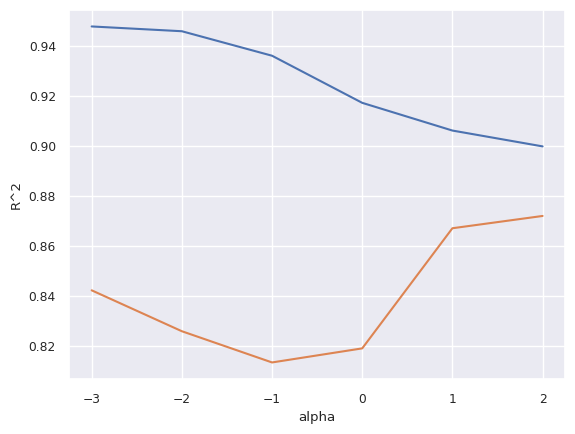

In [193]:
plt.plot(np.log10(alpha_list), train_score)
plt.plot(np.log10(alpha_list), test_score)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()

alpha값: ??

In [194]:
ridge = Ridge(alpha=10)
ridge.fit(train_scaled, y_sub)
print(ridge.score(train_scaled, y_sub))
print(ridge.score(test_scaled, y_test))

0.9060870046399124
0.8670566087745359


In [195]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix

In [196]:
from sklearn.tree import DecisionTreeRegressor

clf_dt = DecisionTreeRegressor()
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print(clf_dt.score(X_train, y_train))

0.9999981457540543


In [197]:
mse = np.sqrt(mean_squared_error(pred_dt, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 2.0826387560098336


In [198]:
from sklearn.ensemble import RandomForestRegressor

rf_clf = RandomForestRegressor()
rf_clf.fit(X_train, y_train)

pred_rf = rf_clf.predict(X_test)

print(rf_clf.score(X_train, y_train))

0.9900889476906201


In [199]:
mse = np.sqrt(mean_squared_error(pred_rf, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.2732155094882598


In [200]:
from sklearn.linear_model import LinearRegression

clf_lr = LinearRegression()
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print(clf_lr.score(X_train, y_train))

0.8904660305769659


In [201]:
mse = np.sqrt(mean_squared_error(pred_lr, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 1.4933002946067828


In [202]:
from sklearn.svm import SVR

clf_svm = SVR()
clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print(clf_svm.score(X_train, y_train))

0.22828065128761177


In [203]:
mse = np.sqrt(mean_squared_error(pred_svm, y_test))
print('평균제곱근오차', mse)

평균제곱근오차 3.928800844920048
